# Table RL agent

In [1]:
import sys
sys.path.insert(0, "../")

from math import radians
from random import uniform
import pickle

from tqdm.notebook import tqdm
import numpy as np
import xarray as xr
import xarray.ufuncs as xrf
import matplotlib.pyplot as plt

from cw.filters import smooth_signal

from pole.cpp import Environment, PIDAgent, TableAgent

In [2]:
env = Environment(0.500, 0.100, radians(30), radians(30))

In [3]:
agent = TableAgent(env,
    min_action=-0.2,
    max_action=0.2,
    min_theta=-radians(30),
    max_theta=radians(30),
    min_theta_dot=-2,
    max_theta_dot=2,
    n_theta=41,
    n_theta_dot=41,
    n_action=11,
    epsilon=0.7,
    gamma=0.9,
    alpha=.1
)

In [6]:
reward_sum = []
avg_steps = 0
n_episodes = 1000000

for episode_idx in tqdm(range(n_episodes)):
    env.reset()
    env.theta = radians(uniform(-30, 30))
    env.theta_dot = radians(uniform(-0.5, 0.5))
    avg_steps += agent.run_episode(1000)
    reward_sum.append(agent.get_reward_sum())

avg_steps /= n_episodes
    
data = agent.get_data()

In [4]:
avg_steps

NameError: name 'avg_steps' is not defined

In [14]:
agent.epsilon = 0
env.reset()
env.theta = radians(uniform(-30, 30))
env.theta_dot = radians(uniform(-0.5, 0.5))
agent.run_episode(1000)
data = agent.get_data()
data

1000

<xarray.Dataset>
Dimensions:    (time: 1000)
Coordinates:
  * time       (time) float64 0.001 0.002 0.003 0.004 ... 0.997 0.998 0.999 1.0
Data variables:
    action     (time) float64 0.09524 0.05714 0.05714 ... 0.05714 0.05714
    delta_v    (time) float64 0.0035 0.0007176 -0.002957 ... 0.0006948 0.0003453
    reward     (time) float64 0.6604 0.6606 0.6609 ... 0.6987 0.6987 0.6988
    theta      (time) float64 -0.09809 -0.09802 -0.09794 ... -0.08593 -0.0859
    theta_dot  (time) float64 0.04543 0.0653 0.08519 ... 0.007701 0.02936

In [52]:
with open("greedy_table_result.pickle", "wb") as f:
    pickle.dump((data, reward_sum), f)

In [ ]:
with open("greedy_table_result.pickle", "rb") as f:
    data, reward_sum = pickle.load(f)

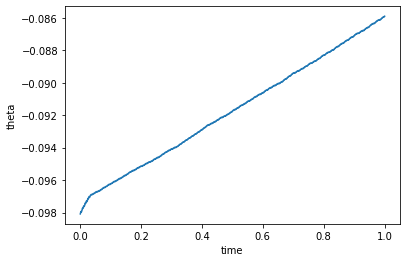

In [15]:
data.theta.plot()

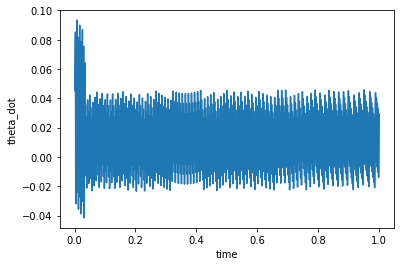

In [16]:
data.theta_dot.plot()

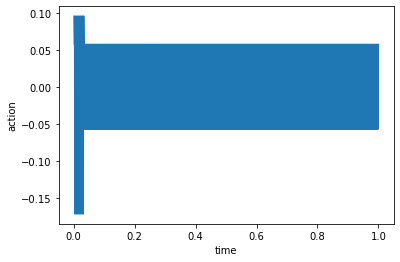

In [20]:
data.action.plot()

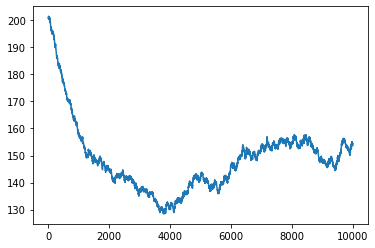

In [39]:
plt.plot(smooth_signal(reward_sum[:10000], "exp", weight=0.001))

<Figure size 864x576 with 0 Axes>

<ipython-input-18-1c13d1272ea1>:3: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(table), cmap='RdBu', aspect="auto", extent=[


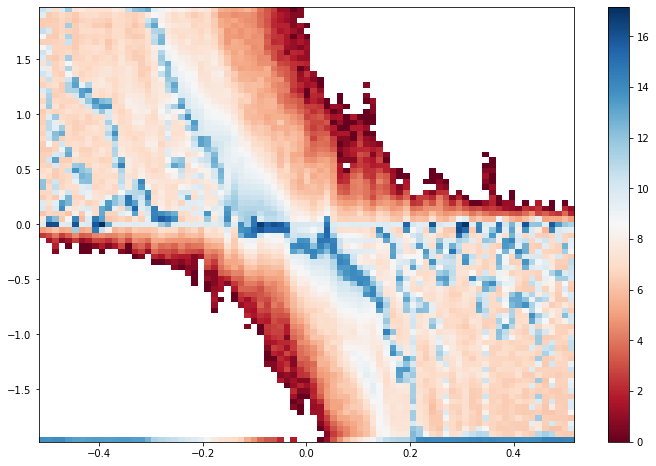

In [18]:
table = np.sum(agent.get_counts(), 0).T
plt.figure(figsize=(12, 8))
plt.imshow(np.log(table), cmap='RdBu', aspect="auto", extent=[
    min(agent.thetas), max(agent.thetas),
    min(agent.theta_dots), max(agent.theta_dots),
])
plt.colorbar()


<Figure size 864x576 with 0 Axes>

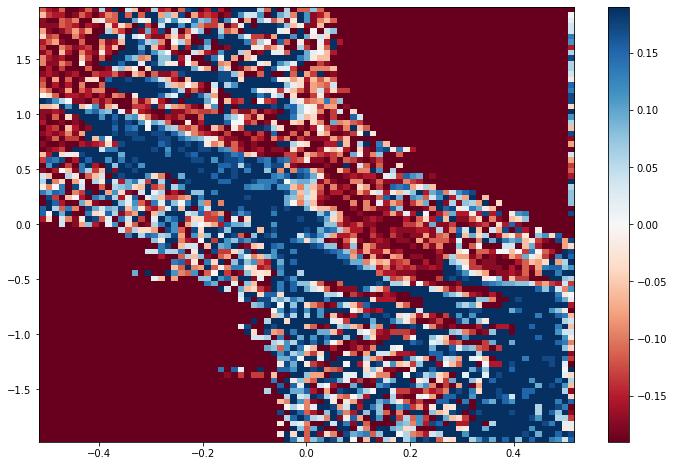

In [19]:
table = agent.get_greedy_action_table().T
plt.figure(figsize=(12, 8))
plt.imshow(table, cmap='RdBu', aspect="auto", extent=[
    min(agent.thetas), max(agent.thetas),
    min(agent.theta_dots), max(agent.theta_dots),
])
plt.colorbar()

In [17]:
agent.thetas

[-0.5108280737544378,
 -0.485286670066716,
 -0.4597452663789941,
 -0.4342038626912722,
 -0.4086624590035503,
 -0.3831210553158284,
 -0.3575796516281065,
 -0.3320382479403846,
 -0.3064968442526627,
 -0.2809554405649408,
 -0.2554140368772189,
 -0.22987263318949702,
 -0.20433122950177512,
 -0.17878982581405323,
 -0.15324842212633133,
 -0.12770701843860943,
 -0.10216561475088759,
 -0.07662421106316569,
 -0.051082807375443795,
 -0.025541403687721898,
 0.0,
 0.025541403687721953,
 0.051082807375443795,
 0.07662421106316575,
 0.10216561475088759,
 0.12770701843860943,
 0.15324842212633139,
 0.17878982581405323,
 0.20433122950177518,
 0.22987263318949702,
 0.255414036877219,
 0.2809554405649408,
 0.30649684425266277,
 0.3320382479403846,
 0.35757965162810657,
 0.3831210553158284,
 0.40866245900355036,
 0.4342038626912722,
 0.45974526637899416,
 0.4852866700667161,
 0.5108280737544378]

In [25]:
41*21*2

1722